In [2]:
import numpy as np
from sklearn.cluster import KMeans
from model.KMeans import kmeans

# The file uses whitespace, not commas
data = np.loadtxt(
    "data/homework_files/kmtest.csv",
    encoding="utf-8-sig"
)

k = 4

#My implementation of KMeans
my_labels, my_centroids = kmeans(data, k)

#SK-Learn's KMeans implementation for comparison
sklearn_model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

sklearn_labels = sklearn_model.fit_predict(data)

print("My centroids:")
print(my_centroids)

print("\nScikit-learn centroids:")
print(sklearn_model.cluster_centers_)

my_inertia = np.sum(
    (data - my_centroids[my_labels]) ** 2
)

print("\nMy inertia:", my_inertia)
print("Scikit-learn inertia:", sklearn_model.inertia_)

My centroids:
[[15.5         5.        ]
 [ 9.8         9.6       ]
 [ 3.16666667  4.        ]
 [ 9.5         4.5       ]]

Scikit-learn centroids:
[[ 9.5         4.5       ]
 [15.5         5.        ]
 [ 3.16666667  4.        ]
 [ 9.8         9.6       ]]

My inertia: 18.333333333333332
Scikit-learn inertia: 18.333333333333332


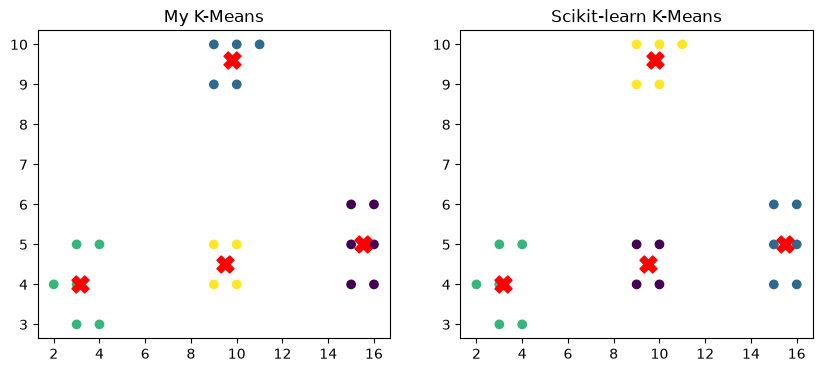

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data[:, 0], data[:, 1], c=my_labels)
axes[0].scatter(
    my_centroids[:, 0],
    my_centroids[:, 1],
    color="red",
    marker="X",
    s=150
)
axes[0].set_title("My K-Means")

axes[1].scatter(data[:, 0], data[:, 1], c=sklearn_labels)
axes[1].scatter(
    sklearn_model.cluster_centers_[:, 0],
    sklearn_model.cluster_centers_[:, 1],
    color="red",
    marker="X",
    s=150
)
axes[1].set_title("Scikit-learn K-Means")

plt.show()

In [20]:
import importlib
import agents.document_agent as document_agent

importlib.reload(document_agent)

transformer_chunks = document_agent.process_documents(
    "data/pdf/transformers",
    chunk_size=1000,
    overlap=200
)

security_chunks = document_agent.process_documents(
    "data/pdf/LLM_Sec",
    chunk_size=1000,
    overlap=200
)

print("Transformer chunks:", len(transformer_chunks))
print("Security chunks:", len(security_chunks))

Processed Attention.pdf, page 1: 4 chunks
Processed Attention.pdf, page 2: 6 chunks
Processed Attention.pdf, page 3: 3 chunks
Processed Attention.pdf, page 4: 4 chunks
Processed Attention.pdf, page 5: 4 chunks
Processed Attention.pdf, page 6: 5 chunks
Processed Attention.pdf, page 7: 5 chunks
Processed Attention.pdf, page 8: 4 chunks
Processed Attention.pdf, page 9: 4 chunks
Processed Attention.pdf, page 10: 4 chunks
Processed Bert.pdf, page 1: 5 chunks
Processed Bert.pdf, page 2: 6 chunks
Processed Bert.pdf, page 3: 5 chunks
Processed Bert.pdf, page 4: 7 chunks
Processed Bert.pdf, page 5: 5 chunks
Processed Bert.pdf, page 6: 6 chunks
Processed Bert.pdf, page 7: 5 chunks
Processed Bert.pdf, page 8: 6 chunks
Processed Bert.pdf, page 9: 6 chunks
Processed Bert.pdf, page 10: 0 chunks
Processed Bert.pdf, page 12: 3 chunks
Processed Bert.pdf, page 13: 5 chunks
Processed Bert.pdf, page 14: 6 chunks
Processed Bert.pdf, page 15: 3 chunks
Processed Bert.pdf, page 16: 4 chunks
Processed LoRA.pdf

In [21]:
import importlib
import agents.document_agent as document_agent

importlib.reload(document_agent)

transformer_chunks = document_agent.process_documents(
    "data/pdf/transformers",
    chunk_size=500,
    overlap=200
)

security_chunks = document_agent.process_documents(
    "data/pdf/LLM_Sec",
    chunk_size=500,
    overlap=200
)

print("Transformer chunks:", len(transformer_chunks))
print("Security chunks:", len(security_chunks))

Processed Attention.pdf, page 1: 10 chunks
Processed Attention.pdf, page 2: 15 chunks
Processed Attention.pdf, page 3: 7 chunks
Processed Attention.pdf, page 4: 9 chunks
Processed Attention.pdf, page 5: 11 chunks
Processed Attention.pdf, page 6: 12 chunks
Processed Attention.pdf, page 7: 11 chunks
Processed Attention.pdf, page 8: 11 chunks
Processed Attention.pdf, page 9: 10 chunks
Processed Attention.pdf, page 10: 9 chunks
Processed Bert.pdf, page 1: 14 chunks
Processed Bert.pdf, page 2: 16 chunks
Processed Bert.pdf, page 3: 13 chunks
Processed Bert.pdf, page 4: 17 chunks
Processed Bert.pdf, page 5: 13 chunks
Processed Bert.pdf, page 6: 15 chunks
Processed Bert.pdf, page 7: 13 chunks
Processed Bert.pdf, page 8: 15 chunks
Processed Bert.pdf, page 9: 14 chunks
Processed Bert.pdf, page 10: 0 chunks
Processed Bert.pdf, page 12: 7 chunks
Processed Bert.pdf, page 13: 13 chunks
Processed Bert.pdf, page 14: 14 chunks
Processed Bert.pdf, page 15: 8 chunks
Processed Bert.pdf, page 16: 11 chunks

In [23]:
import importlib
import agents.embedding_agent as embedding_agent

importlib.reload(embedding_agent)

transformer_embeddings = embedding_agent.create_embeddings(
    transformer_chunks
)

security_embeddings = embedding_agent.create_embeddings(
    security_chunks
)

print(
    "Transformer embeddings:",
    transformer_embeddings.shape
)

print(
    "Security embeddings:",
    security_embeddings.shape
)

Transformer embeddings: (758, 768)
Security embeddings: (736, 768)


In [24]:
assert len(transformer_embeddings) == len(transformer_chunks)
assert len(security_embeddings) == len(security_chunks)

print("Embedding counts are correct.")

Embedding counts are correct.


In [41]:
transformer_labels, transformer_centroids = kmeans(
    transformer_embeddings,
    k=10
)

print("Transformer labels:", transformer_labels.shape)
print("Transformer centroids:", transformer_centroids.shape)
print(
    "Cluster sizes:",
    np.bincount(transformer_labels)
)

Transformer labels: (758,)
Transformer centroids: (10, 768)
Cluster sizes: [134  70  84  76  75  85  58  44  71  61]


In [42]:
security_labels, security_centroids = kmeans(
    security_embeddings,
    k=10
)

print("Security labels:", security_labels.shape)
print("Security centroids:", security_centroids.shape)
print(
    "Cluster sizes:",
    np.bincount(security_labels)
)

Security labels: (736,)
Security centroids: (10, 768)
Cluster sizes: [ 70 130 122  49 149  49  41  23  47  56]


In [43]:
for chunk, label in zip(
    transformer_chunks,
    transformer_labels
):
    chunk["cluster"] = int(label)

In [44]:
for chunk, label in zip(
    security_chunks,
    security_labels
):
    chunk["cluster"] = int(label)

In [48]:
print(transformer_chunks[0]["cluster"])
print(security_chunks[10]["cluster"])

0
4


In [61]:
import importlib
import agents.clustering_agent as clustering_agent

importlib.reload(clustering_agent)


transformer_representatives = find_representatives(
    transformer_chunks,
    transformer_embeddings,
    transformer_labels,
    transformer_centroids
)

security_representatives = find_representatives(
    security_chunks,
    security_embeddings,
    security_labels,
    security_centroids
)

print(
    "Transformer representatives:",
    len(transformer_representatives)
)

print(
    "Security representatives:",
    len(security_representatives)
)

Transformer representatives: 10
Security representatives: 10


In [62]:
from agents.topic_agent import create_topics

transformer_topics = create_topics(
    transformer_representatives
)

security_topics = create_topics(
    security_representatives
)

print("TRANSFORMER TOPICS")

for topic in transformer_topics:
    print(f"\nCluster {topic['cluster']}")
    print("Source:", topic["source"])
    print("Page:", topic["page"])
    print(topic["result"])


print("LLM SECURITY TOPICS")

for topic in security_topics:
    print(f"\nCluster {topic['cluster']}")
    print("Source:", topic["source"])
    print("Page:", topic["page"])
    print(topic["result"])

TRANSFORMER TOPICS

Cluster 0
Source: LoRA.pdf
Page: 9
Topic: Parameter-Efficient Adaptation
Summary: The method proposes using a bottleneck structure to impose a low-rank constraint on weight updates for efficient fine-tuning.

Cluster 1
Source: trillion_Params.pdf
Page: 35
Topic: Mixture-of-Experts Routing
Summary: The text outlines the tensor operations and layout required to dispatch inputs to the correct expert and combine expert outputs using a router.

Cluster 2
Source: trillion_Params.pdf
Page: 14
Topic: Transformer Model Efficiency
Summary: The Switch-based model demonstrates superior sample efficiency and wall-clock speedup compared to standard dense scaling methods.

Cluster 3
Source: Bert.pdf
Page: 2
Topic: Bidirectional Pre-training
Summary: The text discusses how Masked Language Modeling (MLM) and next sentence prediction tasks enable the fusion of left and right context to train deep bidirectional Transformers.

Cluster 4
Source: Bert.pdf
Page: 6
Topic: Language Model Be

In [63]:
from agents.summary_agent import create_final_summary


transformer_summary = create_final_summary(
    transformer_topics
)

security_summary = create_final_summary(
    security_topics
)

In [64]:
print("TRANSFORMER DOCUMENT SUMMARY")
print("=" * 40)
print(transformer_summary)

print("\n\nLLM SECURITY DOCUMENT SUMMARY")
print("=" * 40)
print(security_summary)

TRANSFORMER DOCUMENT SUMMARY
The development of modern language models relies on foundational architectural concepts, most notably the Transformer model, which is a sequence transduction model based entirely on attention, replacing traditional recurrent layers and enabling significantly faster training. Positional encodings are essential components added to models lacking recurrence or convolution to inject information about the relative or absolute position of tokens within a sequence.

Large language models are often pre-trained using methodologies like BERT, which involves bidirectional pre-training through tasks such as Masked Language Modeling (MLM) and next sentence prediction to fuse left and right context. The overall BERT methodology details the pre-training and fine-tuning procedures, detailing the architectural components and application to various Natural Language Processing tasks. Comparative test results and training examples for these language models are often assessed u

In [65]:
import importlib
import agents.clustering_agent as clustering_agent

importlib.reload(clustering_agent)

from agents.clustering_agent import evaluate_k_values

In [66]:
k_values = [3, 5, 10, 30]

print("TRANSFORMER COLLECTION")

transformer_k_results = evaluate_k_values(
    transformer_embeddings,
    k_values
)

print("\nLLM SECURITY COLLECTION")

security_k_results = evaluate_k_values(
    security_embeddings,
    k_values
)

TRANSFORMER COLLECTION
k=3: inertia=417.7458, silhouette=0.0465, smallest cluster=163, largest cluster=335
k=5: inertia=397.7208, silhouette=0.0477, smallest cluster=86, largest cluster=259
k=10: inertia=368.9357, silhouette=0.0478, smallest cluster=44, largest cluster=134
k=30: inertia=322.2284, silhouette=0.0507, smallest cluster=8, largest cluster=55

LLM SECURITY COLLECTION
k=3: inertia=385.3758, silhouette=0.0699, smallest cluster=50, largest cluster=389
k=5: inertia=365.7133, silhouette=0.0486, smallest cluster=50, largest cluster=259
k=10: inertia=339.1440, silhouette=0.0615, smallest cluster=23, largest cluster=149
k=30: inertia=296.5306, silhouette=0.0529, smallest cluster=1, largest cluster=64


In [68]:
import matplotlib.pyplot as plt


def plot_k_results(results, title):
    k_values = [result["k"] for result in results]
    inertias = [result["inertia"] for result in results]
    silhouettes = [
        result["silhouette"]
        for result in results
    ]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(k_values, inertias, marker="o")
    axes[0].set_title(f"{title}: Inertia")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertia")

    axes[1].plot(k_values, silhouettes, marker="o")
    axes[1].set_title(f"{title}: Silhouette")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Silhouette score")

    plt.tight_layout()
    plt.show()

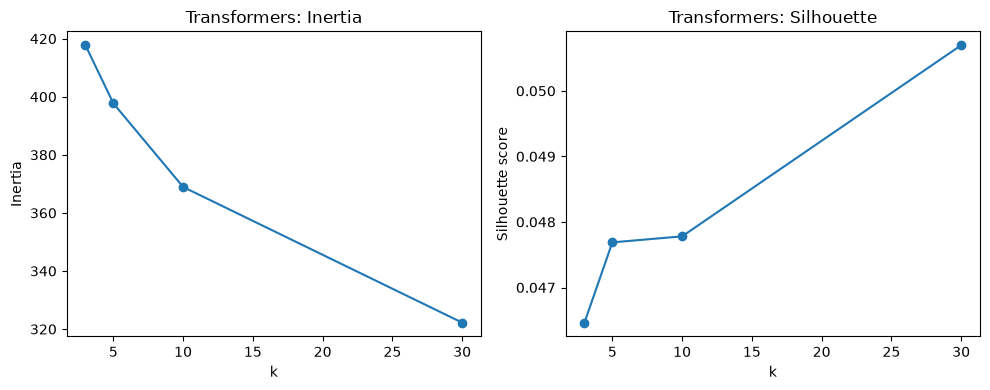

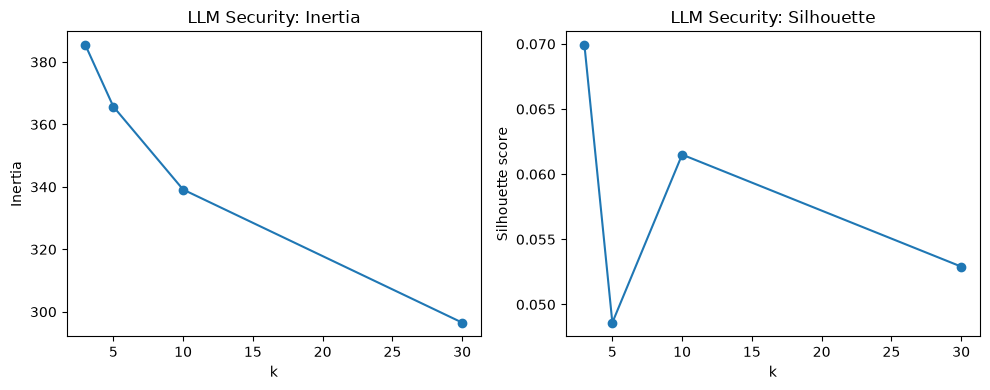

In [69]:
plot_k_results(
    transformer_k_results,
    "Transformers"
)

plot_k_results(
    security_k_results,
    "LLM Security"
)

In [70]:
best_transformer_k = max(
    transformer_k_results,
    key=lambda result: result["silhouette"]
)

best_security_k = max(
    security_k_results,
    key=lambda result: result["silhouette"]
)

print(
    "Best Transformer k:",
    best_transformer_k["k"]
)

print(
    "Best Security k:",
    best_security_k["k"]
)

Best Transformer k: 30
Best Security k: 3


In [71]:
for name, results in [
    ("Transformers", transformer_k_results),
    ("LLM Security", security_k_results),
]:
    print(f"\n{name}")

    for result in results:
        print(
            f"k={result['k']}: "
            f"silhouette={result['silhouette']:.4f}, "
            f"inertia={result['inertia']:.4f}, "
            f"smallest={result['cluster_sizes'].min()}, "
            f"largest={result['cluster_sizes'].max()}"
        )


Transformers
k=3: silhouette=0.0465, inertia=417.7458, smallest=163, largest=335
k=5: silhouette=0.0477, inertia=397.7208, smallest=86, largest=259
k=10: silhouette=0.0478, inertia=368.9357, smallest=44, largest=134
k=30: silhouette=0.0507, inertia=322.2284, smallest=8, largest=55

LLM Security
k=3: silhouette=0.0699, inertia=385.3758, smallest=50, largest=389
k=5: silhouette=0.0486, inertia=365.7133, smallest=50, largest=259
k=10: silhouette=0.0615, inertia=339.1440, smallest=23, largest=149
k=30: silhouette=0.0529, inertia=296.5306, smallest=1, largest=64


In [72]:
selected_transformer = max(
    transformer_k_results,
    key=lambda result: result["silhouette"]
)

selected_security = max(
    security_k_results,
    key=lambda result: result["silhouette"]
)

print("Transformer k:", selected_transformer["k"])
print("Security k:", selected_security["k"])

Transformer k: 30
Security k: 3


In [73]:
from agents.topic_agent import create_topics
from agents.summary_agent import create_final_summary

transformer_topics = create_topics(
    transformer_representatives
)

security_topics = create_topics(
    security_representatives
)

transformer_summary = create_final_summary(
    transformer_topics
)

security_summary = create_final_summary(
    security_topics
)

In [74]:
print("TRANSFORMER SUMMARY")
print(transformer_summary)

print("\nLLM SECURITY SUMMARY")
print(security_summary)

TRANSFORMER SUMMARY
The development of large language models relies on foundational architectural concepts, sophisticated pre-training procedures, and novel methods for efficient adaptation and scaling.

### Model Architecture and Foundations

The Transformer architecture is a sequence transduction model based entirely on attention mechanisms, which significantly speeds up training compared to recurrent architectures. To enable sequence models to process context effectively, positional encodings are added to inject information about the relative or absolute position of tokens, compensating for the lack of recurrence or convolution.

### Pre-training and Context Fusion

The BERT model utilizes bidirectional pre-training by employing masked language modeling and next sentence prediction tasks. This approach is designed to fuse left and right context, enabling the pre-training of deep bidirectional Transformers. The overall BERT procedures involve specific pre-training and fine-tuning pro

In [75]:
from agents.clustering_agent import (
    evaluate_k_values,
    find_representatives,
)
from agents.topic_agent import create_topics
from agents.summary_agent import create_final_summary

# Agent Orchestration via LangGraph

In [77]:
import importlib

import agents.clustering_agent as clustering_agent
import agents.topic_agent as topic_agent
import agents.summary_agent as summary_agent
import agent_orchestration as orchestration

importlib.reload(clustering_agent)
importlib.reload(topic_agent)
importlib.reload(summary_agent)
importlib.reload(orchestration)

<module 'agent_orchestration' from '/Users/hxu10/Desktop/Homeworks/2026-Fall/Advance ML/Assignments /Assignment 1/agent_orchestration.py'>

In [78]:
from agent_orchestration import run_k_study

transformer_reports = run_k_study(
    collection_name="Transformers",
    chunks=transformer_chunks,
    embeddings=transformer_embeddings,
    k_values=(3, 10, 30)
)


Running Transformers with k=3...

Transformers: k=3
Inertia: 417.7458
Silhouette: 0.0465

Cluster 0 - size 260
Medoid: LoRA.pdf, page 7
Excerpt: outperforms several baselines with comparable or fewer trainable parameters. Conﬁdence intervals are shown for experiments we ran. * indicates numbers published in prior works. 5.2 R OBERTA BASE /LARG...
Topic: NLP Model Efficiency
Topic summary: RoBERTa optimizes BERT's pre-training recipe to boost task performance without introducing many trainable parameters, although it is challenged by larger models.

Cluster 1 - size 163
Medoid: trillion_Params.pdf, page 14
Excerpt: g Transformer models with Switch layers or with standard dense model scaling. Left Plot: Switch-Base is more sample eﬃcient than both the T5-Base, and T5-Large variant, which applies 3.5x more FLOPS p...
Topic: Transformer Model Efficiency
Topic summary: The Switch-based model demonstrates superior sample efficiency and wall-clock speedup compared to standard models while va

In [81]:
security_reports = run_k_study(
    collection_name="LLM Security",
    chunks=security_chunks,
    embeddings=security_embeddings,
    k_values=(3, 10, 30)
)


Running LLM Security with k=3...

LLM Security: k=3
Inertia: 385.3758
Silhouette: 0.0699

Cluster 0 - size 389
Medoid: A_Cross_Layer_Security_Survey_of_LLM_Agentic_Systems__Attacks__Defenses__and_Open_Challenges__arvix_Version___Copy_.pdf, page 1
Excerpt: rity threats and defenses for LLM-based agent systems. We introduce a five-layer deployment stack covering infrastructure, model inference, tools, orchestration, and user interaction, and define four ...
Topic: LLM Agent Security
Topic summary: The document introduces a unified threat model and a five-layer deployment stack for addressing security threats and defenses in LLM-based agent systems.

Cluster 1 - size 50
Medoid: A_Cross_Layer_Security_Survey_of_LLM_Agentic_Systems__Attacks__Defenses__and_Open_Challenges__arvix_Version___Copy_.pdf, page 17
Excerpt: s, encrypted ACM Comput. Surv., Vol. 1, No. 1, Article . Publication date: September 2026....
Topic: Academic Citation
Topic summary: The text is a bibliographic reference for a

In [82]:
orchestration.print_assignment_results(
    transformer_reports,
    "Transformers"
)


TRANSFORMERS: k = 3
Inertia: 417.7458
Silhouette score: 0.0465

1. CLUSTER SIZES
Cluster 0: 260 chunks
Cluster 1: 163 chunks
Cluster 2: 335 chunks

2. CLUSTER MEDOIDS
3. GENERATED TOPIC LABELS

------------------------------------------------------------
Cluster: 0
Cluster size: 260
Medoid source: LoRA.pdf
Medoid page: 7
Medoid chunk: 3
Topic label: NLP Model Efficiency
Topic summary: RoBERTa optimizes BERT's pre-training recipe to boost task performance without introducing many trainable parameters, although it is challenged by larger models.
Medoid text:
outperforms several baselines with comparable or fewer trainable parameters. Conﬁdence intervals are shown for experiments we ran. * indicates numbers published in prior works. 5.2 R OBERTA BASE /LARGE RoBERTa (Liu et al., 2019) optimized the pre-training recipe originally proposed in BERT (Devlin et al., 2019a) and boosted the latter’s task performance without introducing many more trainable parameters. While RoBERTa has been overt

In [83]:
orchestration.print_assignment_results(
    security_reports,
    "Security"
)


SECURITY: k = 3
Inertia: 385.3758
Silhouette score: 0.0699

1. CLUSTER SIZES
Cluster 0: 389 chunks
Cluster 1: 50 chunks
Cluster 2: 297 chunks

2. CLUSTER MEDOIDS
3. GENERATED TOPIC LABELS

------------------------------------------------------------
Cluster: 0
Cluster size: 389
Medoid source: A_Cross_Layer_Security_Survey_of_LLM_Agentic_Systems__Attacks__Defenses__and_Open_Challenges__arvix_Version___Copy_.pdf
Medoid page: 1
Medoid chunk: 3
Topic label: LLM Agent Security
Topic summary: The document introduces a unified threat model and a five-layer deployment stack for addressing security threats and defenses in LLM-based agent systems.
Medoid text:
rity threats and defenses for LLM-based agent systems. We introduce a five-layer deployment stack covering infrastructure, model inference, tools, orchestration, and user interaction, and define four trust boundaries that capture security assumptions. We formalize a unified threat model with six attacker types and five security properties